## Hydrogen Radial Wave Functions

For the hydrogen atom, separation of variables gives wavefunctions of the form

$$
\psi_{n\ell m}(r,\theta,\phi)
=
R_{n\ell}(r)Y_\ell^m(\theta,\phi)
$$

The spherical harmonics describe the angular dependence, while the radial wave functions $R_{n\ell}(r)$ describe how the wavefunction changes with distance from the nucleus.

In atomic units, where $a_0=1$, the radial functions can be written in terms of associated Laguerre polynomials. Below, we plot several low-order radial wave functions $R_{n\ell}(r)$ to see how the radial structure changes with the quantum numbers $n$ and $\ell$.

The nodes in these functions are especially important. They correspond to radii where the radial part of the wavefunction changes sign.

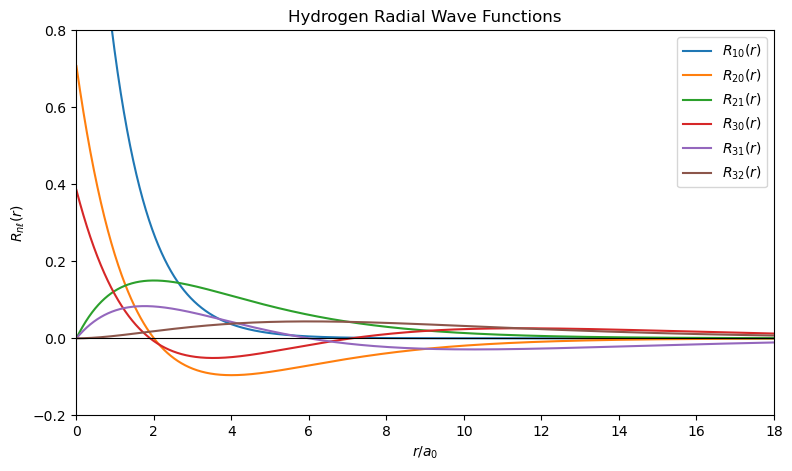

In [24]:
# Hydrogen Radial Wave Functions

import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss

# Radial coordinate in atomic units
r = np.linspace(0, 18, 2000)

# Bohr radius in atomic units
a0 = 1

# States to plot: (n, ell)
states = [
    (1, 0),
    (2, 0),
    (2, 1),
    (3, 0),
    (3, 1),
    (3, 2)
]

def R_nl(r, n, ell):
    """
    Hydrogen radial wave function R_{n ell}(r)
    in atomic units, with a0 = 1.
    """

    # Dimensionless radial variable
    rho = 2*r/(n*a0)

    # Normalization factor
    prefactor = np.sqrt(
        (2/(n*a0))**3
        * ss.factorial(n - ell - 1)
        / (2*n*ss.factorial(n + ell))
    )

    # Associated Laguerre polynomial
    L = ss.eval_genlaguerre(
        n - ell - 1,
        2*ell + 1,
        rho
    )

    return prefactor * np.exp(-rho/2) * rho**ell * L


plt.figure(figsize=(9, 5))

for n, ell in states:

    # Compute the radial wave function
    R = R_nl(r, n, ell)

    plt.plot(
        r,
        R,
        linewidth=1.5,
        label=rf"$R_{{{n}{ell}}}(r)$"
    )

plt.axhline(0, color="black", linewidth=0.8)

# Restrict the visible range to better reveal
# the structure of the higher-order states
plt.xlim(0, 18)
plt.ylim(-0.2, 0.8)

plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$R_{n\ell}(r)$")
plt.title("Hydrogen Radial Wave Functions")

plt.legend()

plt.show()

## Radial Probability Densities

Although the radial wave functions $R_{n\ell}(r)$ are fundamental solutions of the Schrödinger equation, they do not directly represent probabilities. In spherical coordinates, the probability of finding the electron between $r$ and $r+dr$ depends not only on the wavefunction itself, but also on the spherical volume element.

The radial probability density is therefore given by

$$
P(r)=r^2|R_{n\ell}(r)|^2
$$

The extra factor of $r^2$ comes from the volume element in spherical coordinates:

$$
dV = r^2 \sin\theta \, dr \, d\theta \, d\phi
$$

These plots reveal the most probable radial distances for different hydrogen states. Unlike the radial wave functions themselves, the probability densities are always nonnegative and more directly connected to physical measurements.

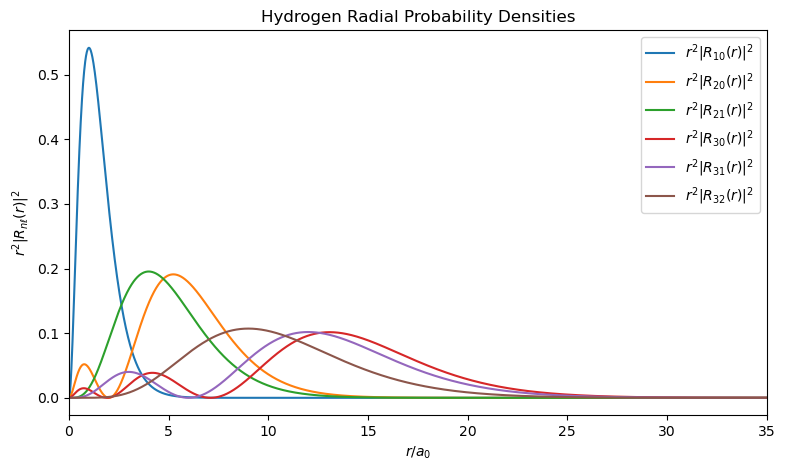

In [26]:
# Hydrogen Radial Probability Densities

# Radial coordinate in atomic units
r = np.linspace(0, 40, 3000)

# Bohr radius in atomic units
a0 = 1

# States to plot: (n, ell)
states = [
    (1, 0),
    (2, 0),
    (2, 1),
    (3, 0),
    (3, 1),
    (3, 2)
]

def R_nl(r, n, ell):
    """
    Hydrogen radial wave function R_{n ell}(r)
    in atomic units, with a0 = 1.
    """

    # Dimensionless radial variable
    rho = 2*r/(n*a0)

    # Normalization factor
    prefactor = np.sqrt(
        (2/(n*a0))**3
        * ss.factorial(n - ell - 1)
        / (2*n*ss.factorial(n + ell))
    )

    # Associated Laguerre polynomial
    L = ss.eval_genlaguerre(
        n - ell - 1,
        2*ell + 1,
        rho
    )

    return prefactor * np.exp(-rho/2) * rho**ell * L


plt.figure(figsize=(9, 5))

for n, ell in states:

    # Compute the radial wave function
    R = R_nl(r, n, ell)

    # Radial probability density
    P = r**2 * np.abs(R)**2

    plt.plot(
        r,
        P,
        linewidth=1.5,
        label=rf"$r^2|R_{{{n}{ell}}}(r)|^2$"
    )

plt.xlim(0, 35)

plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$r^2|R_{n\ell}(r)|^2$")
plt.title("Hydrogen Radial Probability Densities")

plt.legend()

plt.show()

## Hydrogen Orbital Density Slices

The full hydrogen wavefunction separates into a radial part and an angular part:

$$
\psi_{n\ell m}(r,\theta,\phi)
=
R_{n\ell}(r)Y_\ell^m(\theta,\phi)
$$

The physically measurable quantity is not the wavefunction itself, but the probability density:

$$
|\psi_{n\ell m}(r,\theta,\phi)|^2
$$

To visualize this density, we take a two-dimensional slice through space. In the plots below, we use the $xz$-plane, so $y=0$. This lets us see the nodal structure and overall shape of several low-order hydrogen orbitals without needing a full three-dimensional volume plot.

The brightness scale has been adjusted to make faint outer structure and nodal regions more visible.

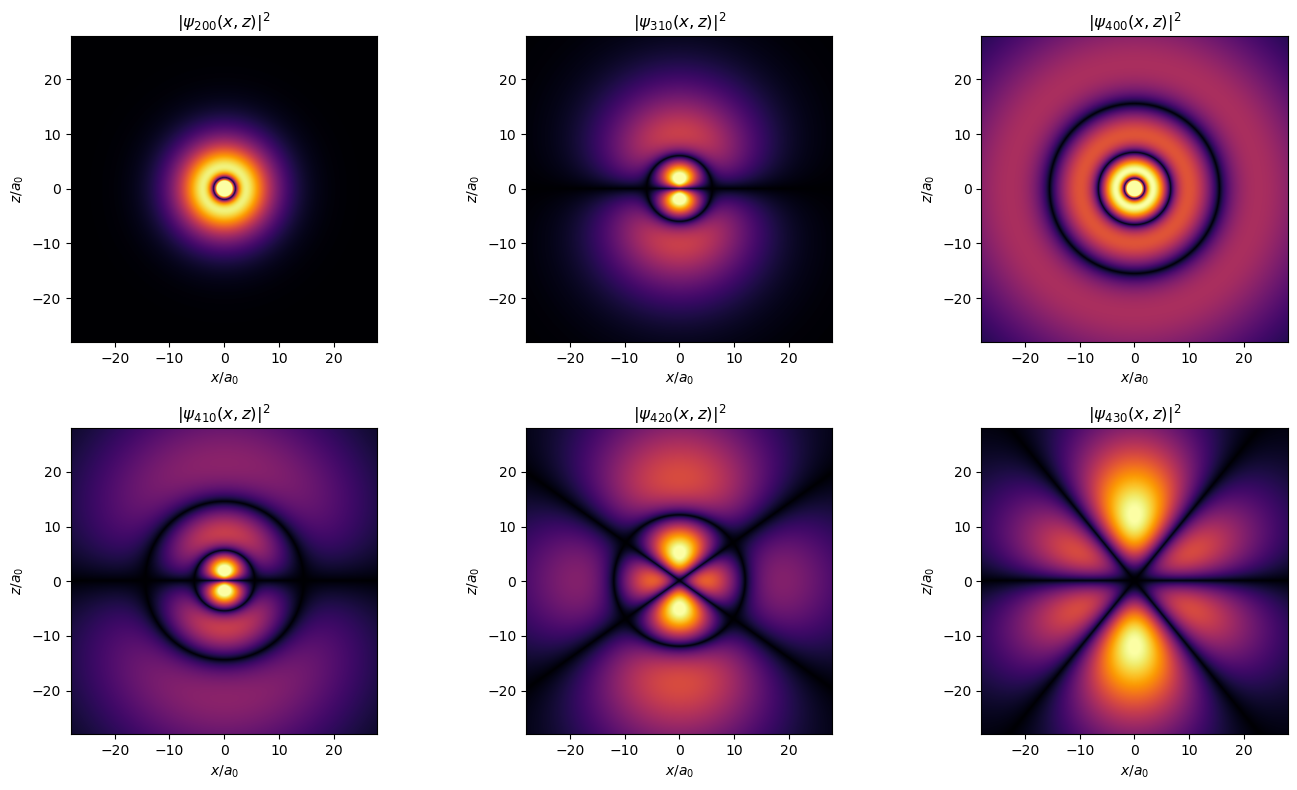

In [34]:
# Hydrogen Orbital Density Slices

# Spatial grid in the xz-plane
x = np.linspace(-28, 28, 700)
z = np.linspace(-28, 28, 700)

X, Z = np.meshgrid(x, z)

# Since we are plotting the xz-plane, y = 0
Y = np.zeros_like(X)

# Convert Cartesian coordinates to spherical coordinates
r = np.sqrt(X**2 + Y**2 + Z**2)

theta = np.arccos(
    np.divide(
        Z,
        r,
        out=np.zeros_like(r),
        where=r != 0
    )
)

phi = np.arctan2(Y, X)

# States chosen to show clearer radial and angular structure
states = [
    (2, 0, 0),
    (3, 1, 0),
    (4, 0, 0),
    (4, 1, 0),
    (4, 2, 0),
    (4, 3, 0)
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

axes = axes.flatten()

for ax, (n, ell, m) in zip(axes, states):

    # Radial part of the hydrogen wavefunction
    R = R_nl(r, n, ell)

    # Angular part of the hydrogen wavefunction
    Y_lm = ss.sph_harm_y(ell, m, theta, phi)

    # Full hydrogen wavefunction
    psi = R * Y_lm

    # Probability density
    density = np.abs(psi)**2

    # Nonlinear brightness scaling
    #
    # This makes faint outer structure visible without
    # changing the nodal pattern of the wavefunction
    density_plot = density**0.35

    ax.imshow(
        density_plot,
        extent=[x.min(), x.max(), z.min(), z.max()],
        origin="lower",
        cmap="inferno",
        vmin=0,
        vmax=np.percentile(density_plot, 99.8)
    )

    ax.set_title(
        rf"$|\psi_{{{n}{ell}{m}}}(x,z)|^2$"
    )

    ax.set_xlabel(r"$x/a_0$")
    ax.set_ylabel(r"$z/a_0$")

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Real Hydrogen Orbital Density Slices

In the previous section, we visualized hydrogen eigenstates built directly from the standard spherical harmonics $Y_\ell^m(\theta,\phi)$. Those functions are generally complex-valued and arise naturally from separation of variables in spherical coordinates.

However, many of the familiar orbital shapes from chemistry are instead constructed from real linear combinations of these spherical harmonics. These combinations produce the recognizable orbitals such as $p_x$, $p_z$, $d_{xz}$, $d_{xy}$, and $d_{x^2-y^2}$.

The separated hydrogen eigenfunctions still have the form

$$
\psi_{n\ell m}(r,\theta,\phi)
=
R_{n\ell}(r)Y_\ell^m(\theta,\phi)
$$

but the angular dependence is now rewritten in terms of real-valued combinations of the spherical harmonics.

In the plots below, we visualize probability densities of the form

$$
|\psi(r,\theta,\phi)|^2
$$

The radial part is still given by the hydrogen radial wave function $R_{n\ell}(r)$, while the angular part produces the familiar real orbital shapes.

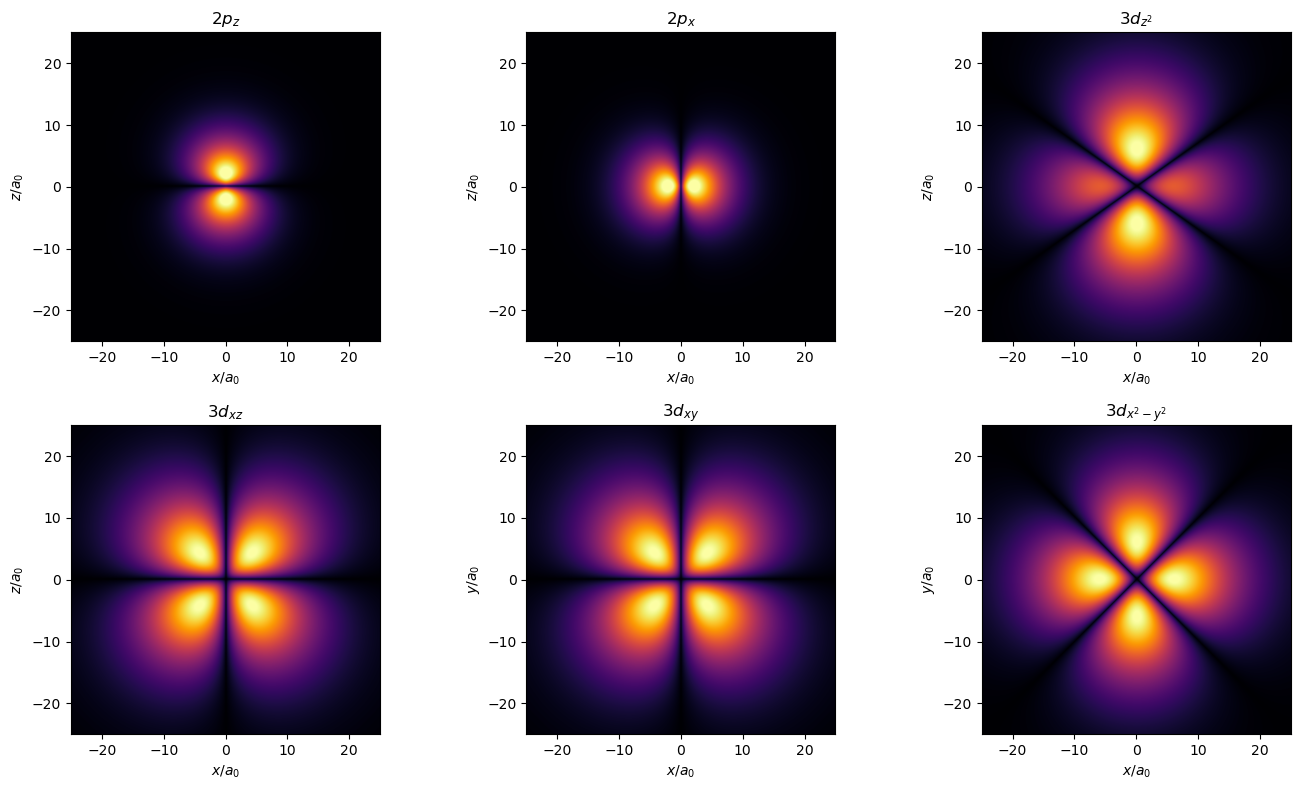

In [35]:
# Real Hydrogen Orbital Density Slices

# Spatial grid
s = np.linspace(-25, 25, 700)
A, B = np.meshgrid(s, s)

# Small number to avoid division by zero at the origin
eps = 1e-12

def spherical_coordinates(X, Y, Z):
    """
    Convert Cartesian coordinates to spherical coordinates.
    """

    r = np.sqrt(X**2 + Y**2 + Z**2)

    theta = np.arccos(
        np.divide(
            Z,
            r,
            out=np.zeros_like(r),
            where=r > eps
        )
    )

    phi = np.arctan2(Y, X)

    return r, theta, phi


def real_orbital_angular_part(orbital, theta, phi):
    """
    Real angular parts corresponding to familiar atomic orbitals.
    
    These are proportional to real spherical harmonics.
    Since we plot probability densities, the overall normalization
    of the angular part is not important for the visual structure.
    """

    if orbital == "p_x":
        return np.sin(theta) * np.cos(phi)

    if orbital == "p_z":
        return np.cos(theta)

    if orbital == "d_z2":
        return 3*np.cos(theta)**2 - 1

    if orbital == "d_xz":
        return np.sin(theta) * np.cos(theta) * np.cos(phi)

    if orbital == "d_xy":
        return np.sin(theta)**2 * np.sin(2*phi)

    if orbital == "d_x2_y2":
        return np.sin(theta)**2 * np.cos(2*phi)


# Orbitals to visualize
#
# Each entry is:
# label, n, ell, orbital type, plotting plane
orbitals = [
    (r"$2p_z$", 2, 1, "p_z", "xz"),
    (r"$2p_x$", 2, 1, "p_x", "xz"),
    (r"$3d_{z^2}$", 3, 2, "d_z2", "xz"),
    (r"$3d_{xz}$", 3, 2, "d_xz", "xz"),
    (r"$3d_{xy}$", 3, 2, "d_xy", "xy"),
    (r"$3d_{x^2-y^2}$", 3, 2, "d_x2_y2", "xy")
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

axes = axes.flatten()

for ax, (label, n, ell, orbital, plane) in zip(axes, orbitals):

    # Choose the slice plane
    if plane == "xz":
        X = A
        Y = np.zeros_like(A)
        Z = B
        xlabel = r"$x/a_0$"
        ylabel = r"$z/a_0$"

    elif plane == "xy":
        X = A
        Y = B
        Z = np.zeros_like(A)
        xlabel = r"$x/a_0$"
        ylabel = r"$y/a_0$"

    # Convert the slice to spherical coordinates
    r, theta, phi = spherical_coordinates(X, Y, Z)

    # Radial part
    R = R_nl(r, n, ell)

    # Real angular part
    angular = real_orbital_angular_part(orbital, theta, phi)

    # Full wavefunction, up to an overall normalization factor
    psi = R * angular

    # Probability density
    density = np.abs(psi)**2

    # Nonlinear brightness scaling
    #
    # This makes the faint outer structure more visible
    # while preserving the nodal pattern
    density_plot = density**0.35

    ax.imshow(
        density_plot,
        extent=[s.min(), s.max(), s.min(), s.max()],
        origin="lower",
        cmap="inferno",
        vmin=0,
        vmax=np.percentile(density_plot, 99.8)
    )

    ax.set_title(label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Three-Dimensional Real Orbital Shapes

Although the previous density slices reveal the internal nodal structure of the orbitals, we can also visualize their angular geometry directly in three dimensions. Many of the familiar orbital shapes from chemistry arise from real linear combinations of the spherical harmonics, producing orbitals such as

$$
p_x, \quad p_z, \quad d_{xz}, \quad d_{xy}, \quad d_{x^2-y^2}, \quad d_{z^2}
$$

To generate these surfaces, we use the magnitude of the angular part of the orbital as the radial distance from the origin:

$$
r(\theta,\phi)=|f(\theta,\phi)|
$$

Here $f(\theta,\phi)$ represents the real angular dependence of the orbital. For example,

$$
p_z \propto \cos\theta
$$

while

$$
d_{z^2} \propto 3\cos^2\theta-1
$$

The modulus is used so that both positive and negative regions appear as outward lobes rather than folding through the origin. These plots therefore isolate the angular structure of the orbitals while suppressing the radial decay of the full hydrogen wavefunction.

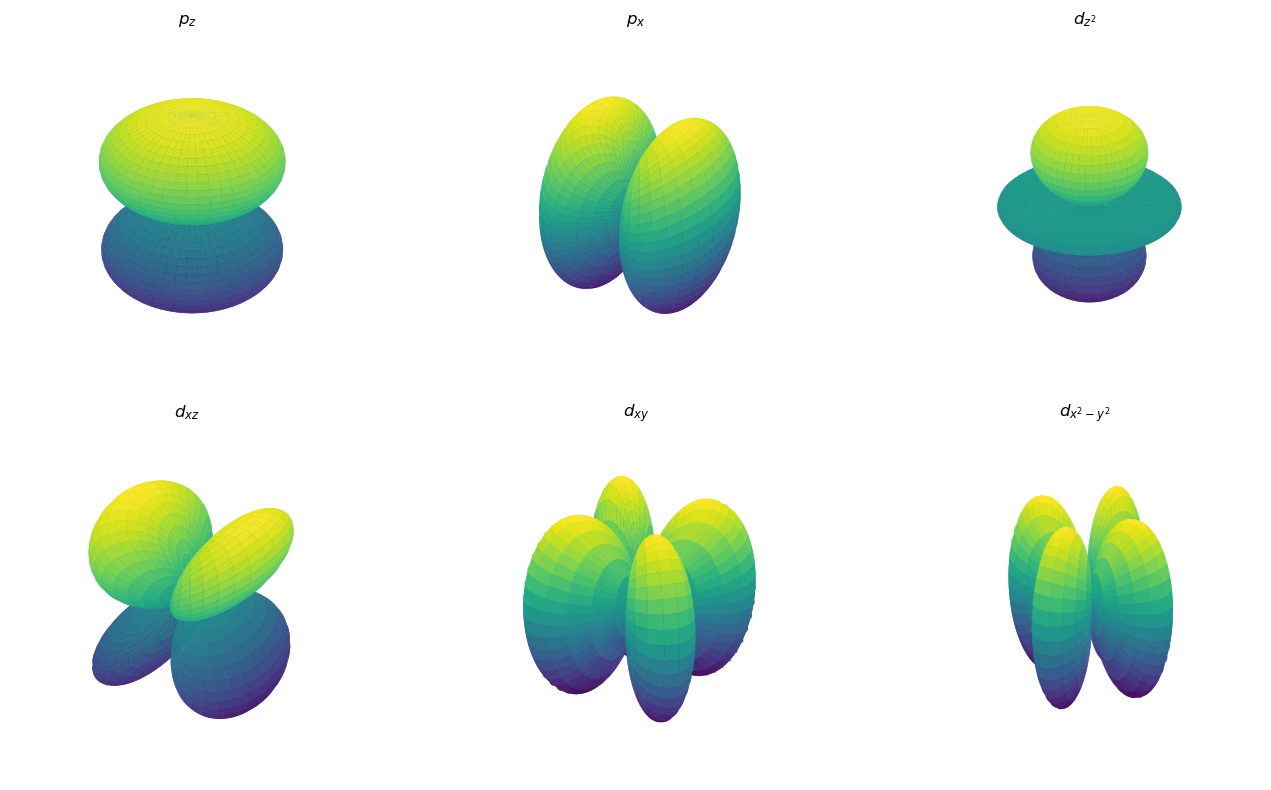

In [39]:
# Three-Dimensional Real Orbital Shapes

# Angular grids
theta = np.linspace(0, np.pi, 250)
phi = np.linspace(0, 2*np.pi, 250)

theta, phi = np.meshgrid(theta, phi)

# Orbitals to visualize
orbitals = [
    (r"$p_z$", "p_z"),
    (r"$p_x$", "p_x"),
    (r"$d_{z^2}$", "d_z2"),
    (r"$d_{xz}$", "d_xz"),
    (r"$d_{xy}$", "d_xy"),
    (r"$d_{x^2-y^2}$", "d_x2_y2")
]

fig = plt.figure(figsize=(14, 8))

for i, (label, orbital) in enumerate(orbitals, start=1):

    # Real angular part of the orbital
    angular = real_orbital_angular_part(orbital, theta, phi)

    # Use the magnitude as the radial distance
    #
    # This creates the familiar orbital lobe shape
    # while ignoring the radial decay
    r = np.abs(angular)

    # Convert spherical coordinates to Cartesian coordinates
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    ax = fig.add_subplot(2, 3, i, projection="3d")

    ax.plot_surface(
        x,
        y,
        z,
        cmap="viridis",
        edgecolor="none",
        alpha=0.95
    )

    ax.set_title(label)

    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()

plt.tight_layout()
plt.show()